# Bench MPI vs OpenMP (ex02)

> Objectif: relancer un benchmark propre (sans recompilation, sans CSV/logs)
sur des tailles $N$ petites jusqu'à 100, puis jusqu'à 500.

- 2 exécutions par $N$: **MPI** (nb de ranks max) et **OpenMP** (nb de threads max)
- Détection auto du max via `sysctl` (macOS)
- Graphe final: **abscisse = N**, **ordonnée = temps (s)**, 2 courbes (MPI / OpenMP)

In [7]:
# Setup (no build, no CSV/logs)

import re
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path('.').resolve()
MPI_DIR = ROOT / 'mpi'
OMP_DIR = ROOT / 'open_mp'

MPI_EXE = MPI_DIR / 'mpi_ex02'
OMP_EXE = OMP_DIR / 'openmp_ex02'

def sh(cmd, *, cwd=ROOT):
    p = subprocess.run(cmd, cwd=cwd, text=True, capture_output=True)
    if p.returncode != 0:
        raise RuntimeError(f"command failed: {cmd}\nstdout:\n{p.stdout}\nstderr:\n{p.stderr}")
    return p.stdout

# macOS: logical CPU count (max useful threads/ranks on this machine)
MAX_WORKERS = int(sh(['sysctl', '-n', 'hw.logicalcpu']).strip())
MPI_NP = MAX_WORKERS
OMP_THREADS = MAX_WORKERS

print('MPI exe  :', MPI_EXE)
print('OpenMP exe:', OMP_EXE)
print('MAX_WORKERS (logical cpu):', MAX_WORKERS)
print('MPI_NP:', MPI_NP)
print('OMP_THREADS:', OMP_THREADS)

MPI exe  : /Users/aurele/AAA_PRO/please/HPC_Project/ex02/mpi/mpi_ex02
OpenMP exe: /Users/aurele/AAA_PRO/please/HPC_Project/ex02/open_mp/openmp_ex02
MAX_WORKERS (logical cpu): 14
MPI_NP: 14
OMP_THREADS: 14


In [8]:
# Fresh benchmark: N small (<=100) then up to 500

N_VALUES = list(range(10, 101, 10)) + [150, 200, 300, 400, 500]

_re_mpi_time = re.compile(r'^time mpi \(max\):\s*([0-9.]+)\s*s\s*$', re.M)
_re_omp_time = re.compile(r'^time omp\s*:\s*([0-9.]+)\s*s\s*$', re.M)

def parse_mpi_time(out: str) -> float:
    return float(_re_mpi_time.search(out).group(1))

def parse_omp_time(out: str) -> float:
    return float(_re_omp_time.search(out).group(1))

rows = []
for n in N_VALUES:
    out_mpi = sh(['mpirun', '-np', str(MPI_NP), str(MPI_EXE), str(n), '-2', '1', '2', '0'], cwd=ROOT)
    rows.append({'model': 'mpi', 'n': n, 'workers': MPI_NP, 'time_s': parse_mpi_time(out_mpi)})

    out_omp = sh([str(OMP_EXE), str(n), '-2', '1', '2', str(OMP_THREADS), '0'], cwd=ROOT)
    rows.append({'model': 'openmp', 'n': n, 'workers': OMP_THREADS, 'time_s': parse_omp_time(out_omp)})

print('OK ran', len(N_VALUES), 'sizes ->', len(rows), 'rows')

OK ran 15 sizes -> 30 rows


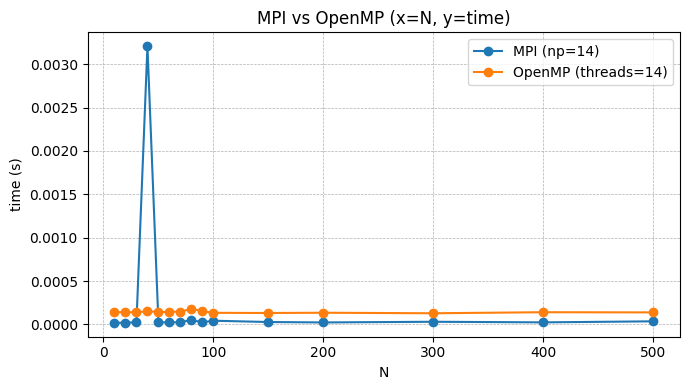

In [9]:
# Plot: x = N, y = time (s), only 2 curves (MPI / OpenMP)

def series(rows, model):
    xs = [r['n'] for r in rows if r['model'] == model]
    ys = [r['time_s'] for r in rows if r['model'] == model]
    return xs, ys

n_mpi, t_mpi = series(rows, 'mpi')
n_omp, t_omp = series(rows, 'openmp')

plt.figure(figsize=(7, 4))
plt.plot(n_mpi, t_mpi, marker='o', label=f'MPI (np={MPI_NP})')
plt.plot(n_omp, t_omp, marker='o', label=f'OpenMP (threads={OMP_THREADS})')
plt.xlabel('N')
plt.ylabel('time (s)')
plt.title('MPI vs OpenMP (x=N, y=time)')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Affichage des temps (pour vérifier clairement l'exécution)

times = {}
for r in rows:
    times.setdefault(r['n'], {})[r['model']] = r['time_s']

print(f"workers: MPI np={MPI_NP} | OpenMP threads={OMP_THREADS}")
print("N\tmpi_time_s\topenmp_time_s")
for n in sorted(times):
    t_m = times[n].get('mpi', float('nan'))
    t_o = times[n].get('openmp', float('nan'))
    print(f"{n}\t{t_m:.6e}\t{t_o:.6e}")

workers: MPI np=14 | OpenMP threads=14
N	mpi_time_s	openmp_time_s
10	1.700000e-05	1.390000e-04
20	2.100000e-05	1.410000e-04
30	2.200000e-05	1.380000e-04
40	3.208000e-03	1.520000e-04
50	2.300000e-05	1.420000e-04
60	2.300000e-05	1.450000e-04
70	2.500000e-05	1.470000e-04
80	5.000000e-05	1.780000e-04
90	2.300000e-05	1.520000e-04
100	4.200000e-05	1.330000e-04
150	2.700000e-05	1.310000e-04
200	2.200000e-05	1.340000e-04
300	3.000000e-05	1.280000e-04
400	2.300000e-05	1.400000e-04
500	3.500000e-05	1.380000e-04
